# Wooldridge Extended Two-Way Fixed Effects (ETWFE)

This tutorial demonstrates the `WooldridgeDiD` estimator (alias: `ETWFE`), which implements Wooldridge's Extended Two-Way Fixed Effects approach — the linear design from Wooldridge (2025) and the nonlinear paths from Wooldridge (2023) — the basis of the Stata `jwdid` package.

**What ETWFE does:** Estimates cohort×time Average Treatment Effects (ATT(g,t)) via a single saturated regression that interacts treatment indicators with cohort×time cells. Unlike standard TWFE, it correctly handles heterogeneous treatment effects across cohorts and time periods. The key insight is to include all cohort×time interaction terms simultaneously, with unit and time fixed effects absorbed via within-transformation.

**Key features:**
- Follows the Stata `jwdid` specification (OLS and nonlinear paths; see Methodology Registry for documented SE/aggregation deviations)
- Supports **linear (OLS)**, **Poisson**, and **logit** link functions
- Nonlinear ATTs use the Average Structural Function (ASF): E[f(η₁)] − E[f(η₀)]
- Delta-method standard errors for all aggregations
- Cluster-robust sandwich variance

**Topics covered:**
1. Basic OLS estimation
2. Cohort×time cell estimates ATT(g,t)
3. Aggregation: event-study, group, simple
4. Poisson QMLE for count / non-negative outcomes
5. Logit for binary outcomes
6. Comparison with Callaway-Sant'Anna
7. All-eventually-treated panels (no never-treated group)
8. Parameter reference and guidance

*Prerequisites: [Tutorial 02](02_staggered_did.ipynb) (Staggered DiD).*

*See also: [Tutorial 15](15_efficient_did.ipynb) for Efficient DiD, [Tutorial 11](11_imputation_did.ipynb) for Imputation DiD.*

In [1]:
import numpy as np
import pandas as pd

from diff_diff import WooldridgeDiD, CallawaySantAnna, generate_staggered_data

try:
    import matplotlib.pyplot as plt
    plt.style.use('seaborn-v0_8-whitegrid')
    HAS_MATPLOTLIB = True
except ImportError:
    HAS_MATPLOTLIB = False
    print("matplotlib not installed - visualization examples will be skipped")

## Data Setup

We use `generate_staggered_data()` to create a balanced panel with 3 treatment cohorts, a never-treated group, and a known ATT of 2.0. This makes it easy to verify estimation accuracy.

We also demonstrate with the **mpdta** dataset (Callaway & Sant'Anna 2021), which contains county-level log employment data with staggered minimum-wage adoption — the canonical benchmark for staggered DiD methods.

In [2]:
# Simulated data
data = generate_staggered_data(
    n_units=300, n_periods=10, treatment_effect=2.0,
    dynamic_effects=False, seed=42
)

print(f"Shape: {data.shape}")
print(f"Cohorts: {sorted(data['first_treat'].unique())}")
print(f"Periods: {sorted(data['period'].unique())}")
print()
data.head()

Shape: (3000, 7)
Cohorts: [np.int64(0), np.int64(3), np.int64(5), np.int64(7)]
Periods: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]



,unit,period,outcome,first_treat,treated,treat,true_effect
0,0,0,11.278161,0,0,0,0.0
1,0,1,11.835615,0,0,0,0.0
2,0,2,11.542112,0,0,0,0.0
3,0,3,11.716260,0,0,0,0.0
4,0,4,12.289791,0,0,0,0.0


## Basic OLS Estimation

The default `method='ols'` fits a single regression with:
- Treatment interaction dummies (one per treatment cohort x post-treatment period cell)
- Unit fixed effects (absorbed via within-transformation)
- Time fixed effects (absorbed via within-transformation)

**The two control groups produce different designs, and the distinction matters below.**

With `control_group='not_yet_treated'` (the default, used in this section), only cells at `t >= g - anticipation` are emitted. Pre-treatment observations from treated units sit in the regression baseline alongside not-yet-treated controls, so there are **no placebo cells and no omitted reference cell** — the lag-only specification.

With `control_group='never_treated'`, pre-treatment interaction indicators are added so only never-treated units define the counterfactual baseline, and pre-treatment coefficients serve as placebo checks. That is the lead-and-lag specification of Wooldridge (2025) Eq. 6.1/6.4, and it is the one that **deliberately omits one cell per cohort — the reference period.** Eq. 6.1 excludes the `g − 1` indicator so that `s = g − 1` is the reference, which is what makes each coefficient a 2×2 DiD against that baseline. The cohort's full block of cell dummies would otherwise sum to its cohort indicator, which the unit fixed effects already absorb, so the design would be rank-deficient and an arbitrary cell — possibly a real post-treatment one — would be dropped instead. Stata `jwdid ... never` omits the same cell. On an unbalanced panel the omitted cell is that cohort's latest *observed* pre-period rather than `g − 1`.

In [3]:
m = WooldridgeDiD()  # default: method='ols'
r = m.fit(data, outcome='outcome', unit='unit', time='period', first_treat='first_treat')

# Compute aggregations
r.aggregate('event_study').aggregate('group').aggregate('simple')

print(r.summary())

    Wooldridge Extended Two-Way Fixed Effects (ETWFE) Results
Method:          ols
Control group:   not_yet_treated
Observations:    3000
Treated units:   210
Control units:   300
Cohort trends:   False
Aggregation w:   cell
----------------------------------------------------------------------
Parameter                Estimate   Std. Err.    t-stat     P>|t|   [95% CI]
----------------------------------------------------------------------
ATT (simple)               1.9817      0.0371    53.422    0.0000***   [1.9090, 2.0544]


## Cohort×Time Cell Estimates ATT(g,t)

The raw building blocks are ATT(g,t) — the treatment effect for cohort `g` at calendar time `t`. These are stored in `r.group_time_effects` and correspond to Stata's regression output table (`first_treat#year#c.__tr__`).

`r` above is the **default** `not_yet_treated` fit, so it contains post-treatment cells (`t >= g`) only. Pre-treatment placebo cells belong to the `never_treated` specification, which the next cell fits explicitly so the two can be compared.

In [4]:
print("Post-treatment ATT(g,t) cells")
print("{:>8} {:>8} | {:>10} {:>10} {:>7} {:>7}".format(
    "cohort", "year", "Coef.", "Std.Err.", "t", "P>|t|"))
print("-" * 60)

for (g, t), v in sorted(r.group_time_effects.items()):
    if t < g:
        continue
    row = "{:>8} {:>8} | {:>10.4f} {:>10.4f} {:>7.2f} {:>7.3f}".format(
        int(g), int(t), v['att'], v['se'], v['t_stat'], v['p_value']
    )
    print(row)

Post-treatment ATT(g,t) cells
  cohort     year |      Coef.   Std.Err.       t   P>|t|
------------------------------------------------------------
       3        3 |     2.0725     0.0941   22.02   0.000
       3        4 |     2.0134     0.0852   23.64   0.000
       3        5 |     2.0190     0.0934   21.63   0.000
       3        6 |     1.9355     0.0804   24.07   0.000
       3        7 |     2.0329     0.1005   20.23   0.000
       3        8 |     1.9614     0.0994   19.73   0.000
       3        9 |     2.0018     0.0839   23.85   0.000
       5        5 |     2.1152     0.0788   26.86   0.000
       5        6 |     1.9647     0.0805   24.42   0.000
       5        7 |     1.8765     0.0824   22.77   0.000
       5        8 |     2.1117     0.0828   25.50   0.000
       5        9 |     1.9286     0.0822   23.45   0.000
       7        7 |     1.8762     0.0801   23.43   0.000
       7        8 |     1.9168     0.0889   21.57   0.000
       7        9 |     1.9321     0.08

In [5]:
# Placebo cells exist only under control_group='never_treated' (the lead-and-lag
# specification). The default not_yet_treated fit `r` above has none.
print(f"default (not_yet_treated) pre-treatment cells: "
      f"{sorted(k for k in r.group_time_effects if k[1] < k[0])}")

r_never = WooldridgeDiD(control_group='never_treated').fit(
    data, outcome='outcome', unit='unit', time='period', first_treat='first_treat')

print("\nPre-treatment placebo ATT(g,t) cells (should be ~0 under parallel trends)")
print("{:>8} {:>8} | {:>10} {:>10} {:>7} {:>7}".format(
    "cohort", "year", "Coef.", "Std.Err.", "t", "P>|t|"))
print("-" * 60)

for (g, t), v in sorted(r_never.group_time_effects.items()):
    if t >= g:
        continue
    print("{:>8} {:>8} | {:>10.4f} {:>10.4f} {:>7.2f} {:>7.3f}".format(
        int(g), int(t), v['att'], v['se'], v['t_stat'], v['p_value']))

# One cell per cohort is absent: the omitted reference period (g-1 here, since
# this panel is balanced). Every coefficient above is measured against it.
for g in sorted(c for c in data['first_treat'].unique() if c > 0):
    present = {t for (gg, t) in r_never.group_time_effects if gg == g}
    missing = sorted(set(data['period'].unique()) - present)
    print(f"cohort {g}: omitted reference cell -> {[(g, t) for t in missing]}")

default (not_yet_treated) pre-treatment cells: []

Pre-treatment placebo ATT(g,t) cells (should be ~0 under parallel trends)
  cohort     year |      Coef.   Std.Err.       t   P>|t|
------------------------------------------------------------
       3        0 |     0.0568     0.1181    0.48   0.630
       3        1 |     0.1425     0.0996    1.43   0.152
       5        0 |    -0.0206     0.1175   -0.18   0.861
       5        1 |     0.0423     0.1086    0.39   0.697
       5        2 |    -0.0191     0.1044   -0.18   0.855
       5        3 |    -0.1359     0.1089   -1.25   0.212
       7        0 |    -0.1344     0.1180   -1.14   0.255
       7        1 |    -0.0188     0.1135   -0.17   0.868
       7        2 |    -0.2664     0.1118   -2.38   0.017
       7        3 |    -0.0605     0.1092   -0.55   0.580
       7        4 |    -0.2214     0.1177   -1.88   0.060
       7        5 |    -0.1768     0.1122   -1.57   0.115
cohort 3: omitted reference cell -> [(np.int64(3), np.int64(

## Aggregation Methods

ETWFE supports four aggregation types, matching Stata's `estat` post-estimation commands:

| Python | Stata | Description |
|--------|-------|-------------|
| `aggregate('event_study')` | `estat event` | By relative time k = t − g |
| `aggregate('group')` | `estat group` | By treatment cohort g |
| `aggregate('calendar')` | `estat calendar` | By calendar time t |
| `aggregate('simple')` | `estat simple` | Overall weighted average ATT |

Standard errors use the delta method, propagating uncertainty from the cell-level ATT covariance matrix.

In [6]:
# Event-study aggregation: ATT by relative time k = t - g
print(r.to_dataframe(level='event_study'))

   relative_period       att        se     t_stat        p_value  conf_int_lo  \
0                0  2.017643  0.048198  41.861506  4.889180e-295     1.923134   
1                1  1.961511  0.048986  40.041886  3.922971e-275     1.865456   
2                2  1.937067  0.050790  38.138931  1.473713e-254     1.837476   
3                3  2.033384  0.059205  34.344547  1.730538e-214     1.917291   
4                4  1.974940  0.064935  30.414086  9.171112e-175     1.847612   
5                5  1.961401  0.099388  19.734829   4.782277e-81     1.766516   
6                6  2.001811  0.083933  23.850075  3.696498e-114     1.837230   

   conf_int_hi  cohort_trends aggregation_weights  
0     2.112152          False                cell  
1     2.057567          False                cell  
2     2.036658          False                cell  
3     2.149477          False                cell  
4     2.102268          False                cell  
5     2.156285          False          

In [7]:
# Group aggregation: ATT averaged across post-treatment periods for each cohort
print(r.to_dataframe(level='group'))

   cohort       att        se     t_stat        p_value  conf_int_lo  \
0       3  2.005216  0.050244  39.909748  1.073586e-273     1.906696   
1       5  1.999333  0.049288  40.564523  7.899715e-281     1.902687   
2       7  1.908365  0.055531  34.365894  1.039854e-214     1.799477   

   conf_int_hi  cohort_trends aggregation_weights  
0     2.103737          False                cell  
1     2.095979          False                cell  
2     2.017253          False                cell  


In [8]:
# Simple ATT: overall weighted average
print(r.summary())

    Wooldridge Extended Two-Way Fixed Effects (ETWFE) Results
Method:          ols
Control group:   not_yet_treated
Observations:    3000
Treated units:   210
Control units:   300
Cohort trends:   False
Aggregation w:   cell
----------------------------------------------------------------------
Parameter                Estimate   Std. Err.    t-stat     P>|t|   [95% CI]
----------------------------------------------------------------------
ATT (simple)               1.9817      0.0371    53.422    0.0000***   [1.9090, 2.0544]


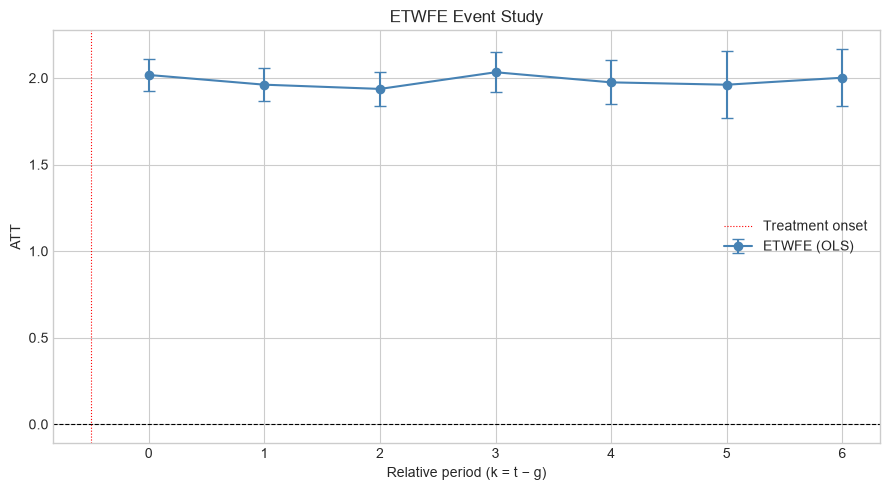

In [9]:
# Event study plot
if HAS_MATPLOTLIB:
    es = r.event_study_effects
    ks   = sorted(es.keys())
    atts = [es[k]['att'] for k in ks]
    lo   = [es[k]['conf_int'][0] for k in ks]
    hi   = [es[k]['conf_int'][1] for k in ks]

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.errorbar(ks, atts, yerr=[np.array(atts) - np.array(lo), np.array(hi) - np.array(atts)],
                fmt='o-', capsize=4, color='steelblue', label='ETWFE (OLS)')
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
    ax.axvline(-0.5, color='red', linestyle=':', linewidth=0.8, label='Treatment onset')
    ax.set_xlabel('Relative period (k = t − g)')
    ax.set_ylabel('ATT')
    ax.set_title('ETWFE Event Study')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Install matplotlib to see the event study plot: pip install matplotlib")

## Poisson QMLE for Count / Non-Negative Outcomes

`method='poisson'` fits a Poisson QMLE regression. This is valid for any non-negative continuous outcome, not just count data — the Poisson log-likelihood produces consistent estimates whenever the conditional mean is correctly specified as exp(Xβ).

The ATT is computed as the **Average Structural Function (ASF) difference**:

$$\text{ATT}(g,t) = \frac{1}{N_{g,t}} \sum_{i \in g,t} \left[\exp(\eta_{i,1}) - \exp(\eta_{i,0})\right]$$

where η₁ = Xβ (with treatment) and η₀ = Xβ − δ (counterfactual without treatment).

This matches Stata's `jwdid y, method(poisson)`.

In [10]:
# Simulate a non-negative outcome (e.g., employment level)
data_pois = data.copy()
data_pois['emp'] = np.exp(data_pois['outcome'] / 4 + 3)  # positive outcome

m_pois = WooldridgeDiD(method='poisson')
r_pois = m_pois.fit(data_pois, outcome='emp', unit='unit', time='period', first_treat='first_treat')
r_pois.aggregate('event_study').aggregate('group').aggregate('simple')

print(r_pois.summary())

    Wooldridge Extended Two-Way Fixed Effects (ETWFE) Results
Method:          poisson
Control group:   not_yet_treated
Observations:    3000
Treated units:   210
Control units:   300
Cohort trends:   False
Aggregation w:   cell
----------------------------------------------------------------------
Parameter                Estimate   Std. Err.    t-stat     P>|t|   [95% CI]
----------------------------------------------------------------------
ATT (simple)             222.6119      9.7423    22.850    0.0000***   [203.5172, 241.7065]


In [11]:
# Cohort×time cells (post-treatment, Poisson)
print("Poisson ATT(g,t) — post-treatment cells")
print("{:>8} {:>8} | {:>10} {:>10} {:>7} {:>7}".format(
    "cohort", "year", "ATT", "Std.Err.", "t", "P>|t|"))
print("-" * 60)

for (g, t), v in sorted(r_pois.group_time_effects.items()):
    if t < g:
        continue
    print("{:>8} {:>8} | {:>10.4f} {:>10.4f} {:>7.2f} {:>7.3f}".format(
        int(g), int(t), v['att'], v['se'], v['t_stat'], v['p_value']
    ))

Poisson ATT(g,t) — post-treatment cells
  cohort     year |        ATT   Std.Err.       t   P>|t|
------------------------------------------------------------
       3        3 |   232.1684    20.1192   11.54   0.000
       3        4 |   237.9872    23.0383   10.33   0.000
       3        5 |   231.4901    19.8361   11.67   0.000
       3        6 |   223.6876    17.1670   13.03   0.000
       3        7 |   237.2743    19.9434   11.90   0.000
       3        8 |   238.1305    19.9106   11.96   0.000
       3        9 |   265.6228    26.4917   10.03   0.000
       5        5 |   219.3397    14.5190   15.11   0.000
       5        6 |   214.5765    17.5795   12.21   0.000
       5        7 |   198.8336    14.8757   13.37   0.000
       5        8 |   242.4799    17.3696   13.96   0.000
       5        9 |   226.3546    17.2521   13.12   0.000
       7        7 |   182.5155    14.1802   12.87   0.000
       7        8 |   202.8975    18.3660   11.05   0.000
       7        9 |   207.435

In [12]:
print(r_pois.to_dataframe(level='event_study'))
print(r_pois.to_dataframe(level='group'))

   relative_period         att         se     t_stat        p_value  \
0                0  209.853525   9.262249  22.656865  1.193811e-113   
1                1  217.094215  11.301395  19.209506   3.081876e-82   
2                2  211.236155  10.015702  21.090498   9.723169e-99   
3                3  234.127753  12.505668  18.721732   3.292711e-78   
4                4  231.207818  12.990070  17.798813   7.218311e-71   
5                5  238.130506  19.910574  11.960002   5.756036e-33   
6                6  265.622807  26.491724  10.026634   1.164183e-23   

   conf_int_lo  conf_int_hi  cohort_trends aggregation_weights  
0   191.699851   228.007200          False                cell  
1   194.943888   239.244543          False                cell  
2   191.605739   230.866571          False                cell  
3   209.617095   258.638412          False                cell  
4   205.747749   256.667887          False                cell  
5   199.106499   277.154513          Fals

## Logit for Binary Outcomes

`method='logit'` fits a logit model and computes ATT as the ASF probability difference:

$$\text{ATT}(g,t) = \frac{1}{N_{g,t}} \sum_{i \in g,t} \left[\Lambda(\eta_{i,1}) - \Lambda(\eta_{i,0})\right]$$

where Λ(·) is the logistic function. Standard errors use the delta method.

This matches Stata's `jwdid y, method(logit)`.

In [13]:
# Create a binary outcome
data_logit = data.copy()
median_val = data_logit.loc[data_logit['period'] == data_logit['period'].min(), 'outcome'].median()
data_logit['hi_outcome'] = (data_logit['outcome'] > median_val).astype(int)

print(f"Binary outcome mean: {data_logit['hi_outcome'].mean():.3f}")

m_logit = WooldridgeDiD(method='logit')
r_logit = m_logit.fit(data_logit, outcome='hi_outcome', unit='unit', time='period', first_treat='first_treat')
r_logit.aggregate('event_study').aggregate('group').aggregate('simple')

print(r_logit.summary())

Binary outcome mean: 0.668
    Wooldridge Extended Two-Way Fixed Effects (ETWFE) Results
Method:          logit
Control group:   not_yet_treated
Observations:    3000
Treated units:   210
Control units:   300
Cohort trends:   False
Aggregation w:   cell
----------------------------------------------------------------------
Parameter                Estimate   Std. Err.    t-stat     P>|t|   [95% CI]
----------------------------------------------------------------------
ATT (simple)               0.2460      0.0311     7.919    0.0000***   [0.1851, 0.3069]


In [14]:
print(r_logit.to_dataframe(level='group'))

   cohort       att        se    t_stat       p_value  conf_int_lo  \
0       3  0.238387  0.048375  4.927931  8.310506e-07     0.143574   
1       5  0.229646  0.045347  5.064162  4.101997e-07     0.140767   
2       7  0.287403  0.053016  5.421110  5.923009e-08     0.183495   

   conf_int_hi  cohort_trends aggregation_weights  
0     0.333200          False                cell  
1     0.318525          False                cell  
2     0.391312          False                cell  


## mpdta: Real-World Example

The **mpdta** dataset (Callaway & Sant'Anna 2021) contains county-level log employment (`lemp`) data with staggered minimum-wage adoption (`first_treat` = year of treatment, 0 = never treated). It is the canonical benchmark for staggered DiD methods.

This follows Stata's `jwdid lemp, ivar(countyreal) tvar(year) gvar(first_treat)` specification. See the Methodology Registry for documented SE/aggregation deviations.

In [15]:
from diff_diff import load_mpdta

mpdta = load_mpdta()
print(f"mpdta loaded: {mpdta.shape}")
print(f"Cohorts: {sorted(mpdta['first_treat'].unique())}")

mpdta loaded: (2500, 7)
Cohorts: [np.int64(0), np.int64(2004), np.int64(2006), np.int64(2007)]


In [16]:
# OLS — matches: jwdid lemp, ivar(countyreal) tvar(year) gvar(first_treat)
m_ols = WooldridgeDiD(method='ols')
r_ols = m_ols.fit(mpdta, outcome='lemp', unit='countyreal', time='year', first_treat='first_treat')
r_ols.aggregate('event_study').aggregate('group').aggregate('simple')
print(r_ols.to_dataframe(level='event_study'))

   relative_period       att        se    t_stat   p_value  conf_int_lo  \
0                0 -0.031067  0.013621 -2.280835  0.022664    -0.057780   
1                1 -0.052235  0.018873 -2.767725  0.005697    -0.089247   
2                2 -0.136078  0.035455 -3.837999  0.000128    -0.205612   
3                3 -0.104707  0.033874 -3.091059  0.002022    -0.171140   

   conf_int_hi  cohort_trends aggregation_weights  
0    -0.004354          False                cell  
1    -0.015222          False                cell  
2    -0.066544          False                cell  
3    -0.038275          False                cell  


In [17]:
# cohort x time ATT cells (post-treatment)
# Matches Stata: first_treat#year#c.__tr__ output table
print("ATT(g,t) — post-treatment cells (matches Stata jwdid output)")
print("{:>6} {:>6} | {:>9} {:>9} {:>7} {:>7}".format(
    "cohort", "year", "Coef.", "Std.Err.", "t", "P>|t|"))
print("-" * 55)
for (g, t), v in sorted(r_ols.group_time_effects.items()):
    if t < g:
        continue
    print("{:>6} {:>6} | {:>9.4f} {:>9.4f} {:>7.2f} {:>7.3f}".format(
        g, t, v['att'], v['se'], v['t_stat'], v['p_value']))

ATT(g,t) — post-treatment cells (matches Stata jwdid output)
cohort   year |     Coef.  Std.Err.       t   P>|t|
-------------------------------------------------------
  2004   2004 |   -0.0194    0.0224   -0.87   0.387
  2004   2005 |   -0.0783    0.0305   -2.57   0.010
  2004   2006 |   -0.1361    0.0355   -3.84   0.000
  2004   2007 |   -0.1047    0.0339   -3.09   0.002
  2006   2006 |    0.0025    0.0199    0.13   0.900
  2006   2007 |   -0.0392    0.0240   -1.63   0.103
  2007   2007 |   -0.0431    0.0184   -2.34   0.019


In [18]:
# Poisson — matches: gen emp=exp(lemp) / jwdid emp, method(poisson)
mpdta['emp'] = np.exp(mpdta['lemp'])

m_pois2 = WooldridgeDiD(method='poisson')
r_pois2 = m_pois2.fit(mpdta, outcome='emp', unit='countyreal', time='year', first_treat='first_treat')
r_pois2.aggregate('event_study').aggregate('group').aggregate('simple')

print(r_pois2.to_dataframe(level='event_study'))
print(r_pois2.to_dataframe(level='group'))
print(r_pois2.summary())

   relative_period         att         se    t_stat   p_value  conf_int_lo  \
0                0  -25.572049  21.809918 -1.172496  0.240998   -68.318703   
1                1    0.873630  53.217084  0.016416  0.986902  -103.429938   
2                2  -76.746573  28.036277 -2.737402  0.006193  -131.696667   
3                3 -102.357517  41.590684 -2.461068  0.013852  -183.873759   

   conf_int_hi  cohort_trends aggregation_weights  
0    17.174605          False                cell  
1   105.177198          False                cell  
2   -21.796478          False                cell  
3   -20.841275          False                cell  
   cohort        att         se    t_stat   p_value  conf_int_lo  conf_int_hi  \
0    2004 -56.868740  24.371745 -2.333388  0.019628  -104.636481    -9.100998   
1    2006  58.439881  72.503696  0.806026  0.420228   -83.664751   200.544514   
2    2007 -65.187913  23.560932 -2.766780  0.005661  -111.366491   -19.009336   

   cohort_trends aggrega

## Comparison with Callaway-Sant'Anna

ETWFE and Callaway-Sant'Anna are both valid for staggered designs. Under homogeneous treatment effects and additive parallel trends, they should produce similar ATT(g,t) point estimates. Key differences:

| Aspect | WooldridgeDiD (ETWFE) | CallawaySantAnna |
|--------|----------------------|------------------|
| Approach | Single saturated regression | Separate 2×2 DiD per cell |
| Nonlinear outcomes | Yes (Poisson, Logit) | No |
| Covariates | Via regression (linear index) | OR, IPW, DR |
| SE for aggregations | Delta method | Multiplier bootstrap |
| Stata equivalent | `jwdid` | `csdid` |

In [19]:
# Compare overall ATT: ETWFE vs Callaway-Sant'Anna
cs = CallawaySantAnna()
r_cs = cs.fit(data, outcome='outcome', unit='unit', time='period', first_treat='first_treat')

m_etwfe = WooldridgeDiD(method='ols')
r_etwfe = m_etwfe.fit(data, outcome='outcome', unit='unit', time='period', first_treat='first_treat')
r_etwfe.aggregate('event_study').aggregate('simple')

print("Overall ATT Comparison (true effect = 2.0)")
print("=" * 60)
print("{:<25} {:>10} {:>10} {:>12}".format("Estimator", "ATT", "SE", "95% CI"))
print("-" * 60)

for name, est_r in [("WooldridgeDiD (ETWFE)", r_etwfe), ("CallawaySantAnna", r_cs)]:
    ci = est_r.overall_conf_int
    print("{:<25} {:>10.4f} {:>10.4f} [{:.3f}, {:.3f}]".format(
        name, est_r.overall_att, est_r.overall_se, ci[0], ci[1]
    ))

Overall ATT Comparison (true effect = 2.0)
Estimator                        ATT         SE       95% CI
------------------------------------------------------------
WooldridgeDiD (ETWFE)         1.9817     0.0371 [1.909, 2.054]
CallawaySantAnna              1.9754     0.0528 [1.872, 2.079]


/var/folders/bh/mzf05nq92hs6t7vn2ssvfhpr0000gn/T/ipykernel_96398/1757607880.py:2: FutureWarning: CallawaySantAnna.fit(aggregate=) is deprecated and will be removed in 4.0. Fit once, then aggregate as a post-fit step: results = CallawaySantAnna().fit(...); results.aggregate('event_study') / .aggregate('group') / .aggregate('simple'). balance_e moves onto aggregate() alongside it: results.aggregate('event_study', balance_e=2).
  r_cs_es = CallawaySantAnna().fit(


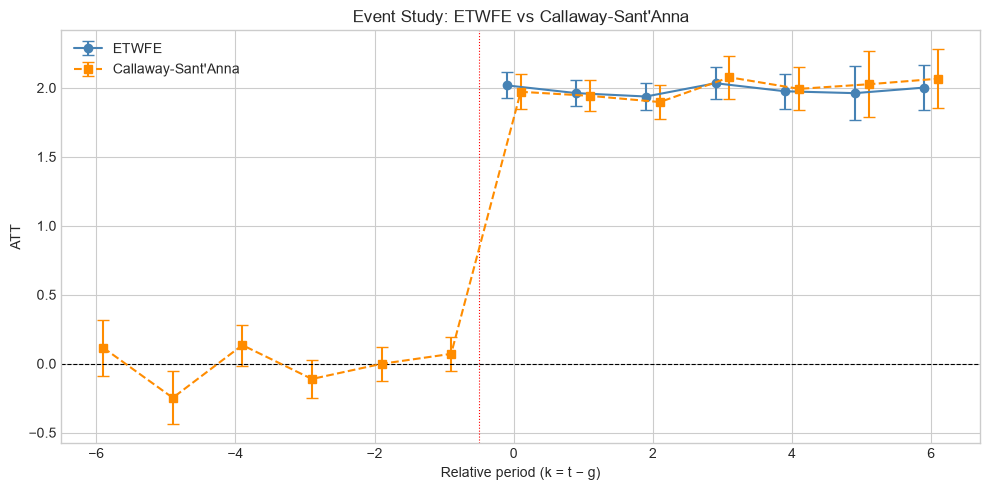

In [20]:
# Event-study comparison
r_cs_es = CallawaySantAnna().fit(
    data, outcome='outcome', unit='unit', time='period',
    first_treat='first_treat', aggregate='event_study'
)

if HAS_MATPLOTLIB:
    es_etwfe = r_etwfe.event_study_effects
    es_cs    = {int(row['relative_period']): row
                for _, row in r_cs_es.to_dataframe(level='event_study').iterrows()}

    ks = sorted(es_etwfe.keys())

    fig, ax = plt.subplots(figsize=(10, 5))
    offset = 0.1

    atts_e = [es_etwfe[k]['att'] for k in ks]
    lo_e   = [es_etwfe[k]['conf_int'][0] for k in ks]
    hi_e   = [es_etwfe[k]['conf_int'][1] for k in ks]
    ax.errorbar([k - offset for k in ks], atts_e,
                yerr=[np.array(atts_e) - np.array(lo_e), np.array(hi_e) - np.array(atts_e)],
                fmt='o-', capsize=4, color='steelblue', label='ETWFE')

    ks_cs  = sorted(es_cs.keys())
    atts_cs = [es_cs[k]['effect'] for k in ks_cs]
    lo_cs   = [es_cs[k]['conf_int_lower'] for k in ks_cs]
    hi_cs   = [es_cs[k]['conf_int_upper'] for k in ks_cs]
    ax.errorbar([k + offset for k in ks_cs], atts_cs,
                yerr=[np.array(atts_cs) - np.array(lo_cs), np.array(hi_cs) - np.array(atts_cs)],
                fmt='s--', capsize=4, color='darkorange', label='Callaway-Sant\'Anna')

    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
    ax.axvline(-0.5, color='red', linestyle=':', linewidth=0.8)
    ax.set_xlabel('Relative period (k = t − g)')
    ax.set_ylabel('ATT')
    ax.set_title('Event Study: ETWFE vs Callaway-Sant\'Anna')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Install matplotlib to see the comparison plot: pip install matplotlib")

## All-Eventually-Treated Panels (no never-treated group)

Many applied panels have **no never-treated units** — every unit is eventually
treated, just at different times. At the late periods where *everyone* is
treated there is no untreated outcome left to difference against, so those
`ATT(g, t)` are not identified.

Wooldridge (2025) Section 5.4 gives the answer: the **last cohort serves as the
reference**, and "all variables in regression (5.3) involving `dT_i` get
dropped". `WooldridgeDiD` implements that — it removes the unsupported periods
before estimating and tells you it did.

Use `control_group="not_yet_treated"` (the default); `"never_treated"` raises
when there are no never-treated units to use.


In [21]:
import warnings

# Three cohorts, no never-treated group: everyone is treated by t=8.
rng = np.random.default_rng(7)
rows = []
for u in range(200):
    g = 3 if u < 70 else (5 if u < 140 else 8)
    for t in range(1, 10):
        rows.append({"unit": u, "time": t, "cohort": g,
                     "y": rng.standard_normal() + 1.5 * (t >= g)})
all_treated = pd.DataFrame(rows)

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    res_at = WooldridgeDiD(control_group="not_yet_treated").fit(
        all_treated, outcome="y", unit="unit", time="time", first_treat="cohort"
    )

for w in caught:
    print(f"WARNING: {w.message}\n")

print(f"overall ATT = {res_at.overall_att:.4f}   (true effect: 1.5)")
print(f"estimated cohorts = {sorted(int(g) for g in res_at.groups)}")
print(f"cells = {sorted((int(g), int(t)) for g, t in res_at.group_time_effects)}")




overall ATT = 1.5502   (true effect: 1.5)
estimated cohorts = [3, 5]
cells = [(3, 3), (3, 4), (3, 5), (3, 6), (3, 7), (5, 5), (5, 6), (5, 7)]


Two things to read from that output.

**The estimation sample shrank, and you were told.** Periods 8 and 9 have no
untreated unit, so their rows are dropped before the solve. Stata's `jwdid`
performs the same reduction but reports only a smaller `N` — here the periods,
the row count and the reason are all stated. If you are wrapping this in a
pipeline, surface these warnings.

**Cohort 8 has no estimates.** It is the reference — the role a never-treated
group would otherwise play — so it receives no cells and is excluded from
`results.groups`. That is the Section 5.4 normalization, not a failure.

The retained ATTs are the **absolute** effects (≈ 1.5 here), not effects
relative to the last cohort, because cohort 8 is untreated throughout every
period that survives.

> **Covariates on these panels.** `exovar` / `xgvar`, and `xtvar` with
> `demean_covariates=False`, are still rank-deficient here: `D_g × X` is built
> for the last cohort too, which the paper's rule would drop. Coefficients are
> unaffected, but `rank_deficient_action="error"` will raise. **Default `xtvar`
> (`demean_covariates=True`) is full rank** and fits normally. Tracked as
> follow-up work.


## Summary

**Key takeaways:**

1. **ETWFE via a single regression**: all ATT(g,t) cells estimated jointly, not separately — computationally efficient and internally consistent
2. **OLS path** follows the Stata `jwdid` specification: unit + time FEs (absorbed via within-transformation), treatment interaction dummies
3. **Nonlinear paths** (Poisson, Logit) use the ASF formula: E[f(η₁)] − E[f(η₀)] — the only valid ATT definition for nonlinear models
4. **Four aggregations** mirror Stata's `estat` commands: event, group, calendar, simple
5. **Delta-method SEs** for all aggregations, including nonlinear paths
6. **All-eventually-treated panels** estimate via the Section 5.4 normalization: the last cohort is the reference, unsupported periods are dropped, and the reduction is always reported
7. **When to prefer ETWFE**: nonlinear outcomes, or when a single-regression framework is preferred
8. **When to prefer CS/ImputationDiD**: covariate adjustment via IPW/DR, or multiplier bootstrap inference

**Parameter reference:**

| Parameter | Default | Description |
|-----------|---------|-------------|
| `method` | `'ols'` | `'ols'`, `'poisson'`, or `'logit'` |
| `control_group` | `'not_yet_treated'` | `'not_yet_treated'` or `'never_treated'` |
| `anticipation` | `0` | Anticipation periods before treatment |
| `alpha` | `0.05` | Significance level |
| `cluster` | `None` | Column for clustering (default: unit variable) |

**References:**
- Wooldridge, J. M. (2025). Two-Way Fixed Effects, the Two-Way Mundlak Regression, and Difference-in-Differences Estimators. *Empirical Economics*, 69(5), 2545–2587. Published version of SSRN 3906345 / NBER Working Paper 29154; cited as Wooldridge (2025) throughout this tutorial, including Eq. 6.1/6.4 (reference period) and Section 5.4 (all-eventually-treated panels).
- Wooldridge, J. M. (2023). Simple approaches to nonlinear difference-in-differences with panel data. *The Econometrics Journal*, 26(3), C31–C66.
- Friosavila, F. (2021). `jwdid`: Stata module for ETWFE. SSC s459114.

*See also: [Tutorial 02](02_staggered_did.ipynb) for Callaway-Sant'Anna, [Tutorial 15](15_efficient_did.ipynb) for Efficient DiD.*